In [67]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [68]:
df = pd.read_csv('./Churn_Modelling.csv')

In [69]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [70]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [71]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [72]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [73]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [74]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [75]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [76]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [78]:
!pip install tensorflow

In [79]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [80]:
model = Sequential()

model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

/Users/rachitgoyal/Desktop/deep-learning/venv/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [99]:
history = model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4950
Epoch 2/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4950
Epoch 3/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4951
Epoch 4/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 681us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4950
Epoch 5/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4950
Epoch 6/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4951
Epoch 7/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - accuracy: 0.7958 - loss: 0.4987 - val_accuracy: 0.7969 - val_loss: 0.4950
Epoch 8/100
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step - accuracy: 0.7958 - loss: 0

In [93]:
y_pred = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step


In [94]:
y_pred

array([[0.25934184],
       [0.23851448],
       [0.23851448],
       ...,
       [0.23851448],
       [0.23851448],
       [0.25934184]], shape=(2000, 1), dtype=float32)

In [95]:
y_pred = y_pred.argmax(axis=-1)

In [96]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.7975

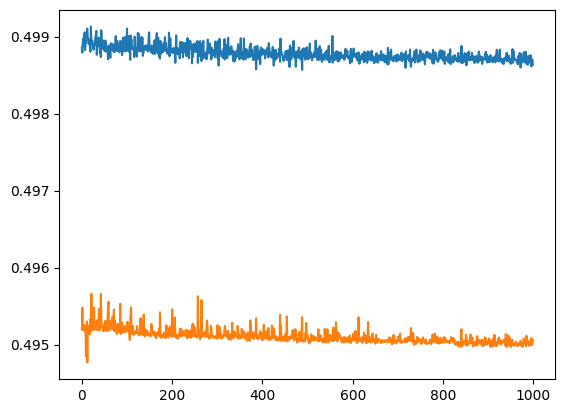

In [97]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

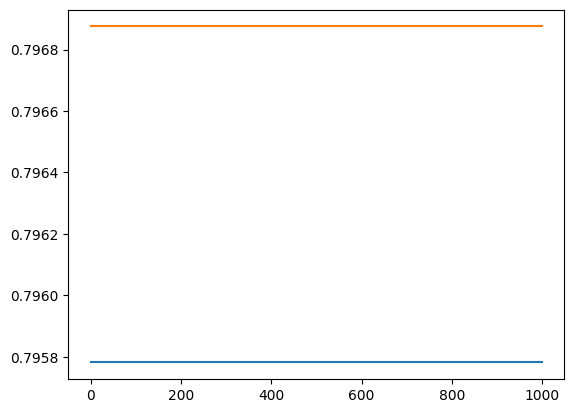

In [98]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])